In [34]:
from sklearn.model_selection import train_test_split
import pandas as pd
def split_data(df_clean):

    Y = df_clean['is_fraudulent']
    X = df_clean.drop(columns=['is_fraudulent'], axis=1)   
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=42, stratify=Y)

    # Print dataset sizes
    print(f"Training Set: {X_train.shape[0]} rows")
    print(f"Testing Set: {X_test.shape[0]} rows")  

    return X_train, X_test, y_train, y_test 

df_clean = pd.read_csv('../backend_app/training_data/clean_dataset_2.csv')
df_clean.drop(columns=['transaction_velocity', 'hour', 'lon', "transaction_ratio"], inplace=True)
X_train, X_test, y_train, y_test = split_data(df_clean)
print(f"X_train : {X_train.shape}")
print(f"X_train : {X_test.shape}")


Training Set: 450000 rows
Testing Set: 50000 rows
X_train : (450000, 4)
X_train : (50000, 4)


In [35]:
df_clean.head()

,transaction_type,amount,merchant_category,is_fraudulent,rolling_avg_amount
0,0,0.394423,0,0,0.006393
1,1,0.320540,1,0,0.003217
2,2,0.434601,2,0,0.009168
3,1,0.146250,1,0,0.000412
4,2,0.493229,2,0,0.015365


•	transaction_type, merchant_category, amount, risk_score, rolling_avg_amount, transactions_per_hour

In [36]:
df_clean.columns

Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'rolling_avg_amount'],
      dtype='object')

In [37]:
df_clean.columns

Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'rolling_avg_amount'],
      dtype='object')

In [38]:
df_clean.columns

Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'rolling_avg_amount'],
      dtype='object')

In [39]:
X_train.var()

transaction_type      0.687726
amount                0.052040
merchant_category     3.160693
rolling_avg_amount    0.036305
dtype: float64

In [40]:
X_train['transaction_type'].value_counts()

transaction_type
2    281027
1     56476
3     56252
0     56245
Name: count, dtype: int64

In [41]:
print(X_train['amount'].max())
print(X_train['amount'].min())

1.0
0.0


In [42]:
df_clean.head()

,transaction_type,amount,merchant_category,is_fraudulent,rolling_avg_amount
0,0,0.394423,0,0,0.006393
1,1,0.320540,1,0,0.003217
2,2,0.434601,2,0,0.009168
3,1,0.146250,1,0,0.000412
4,2,0.493229,2,0,0.015365


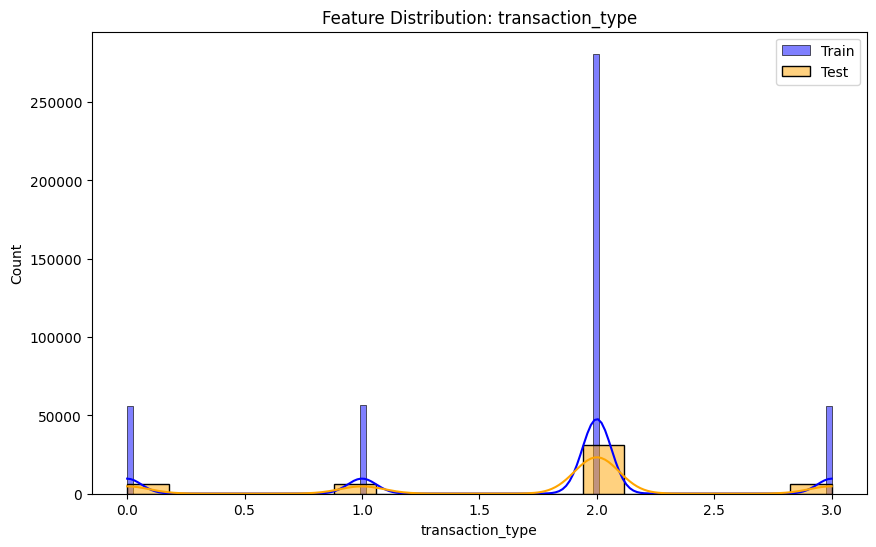

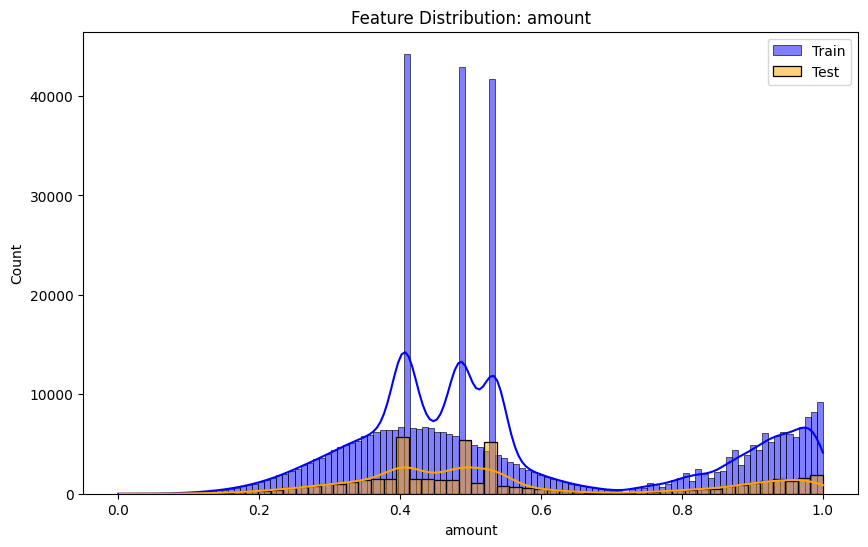

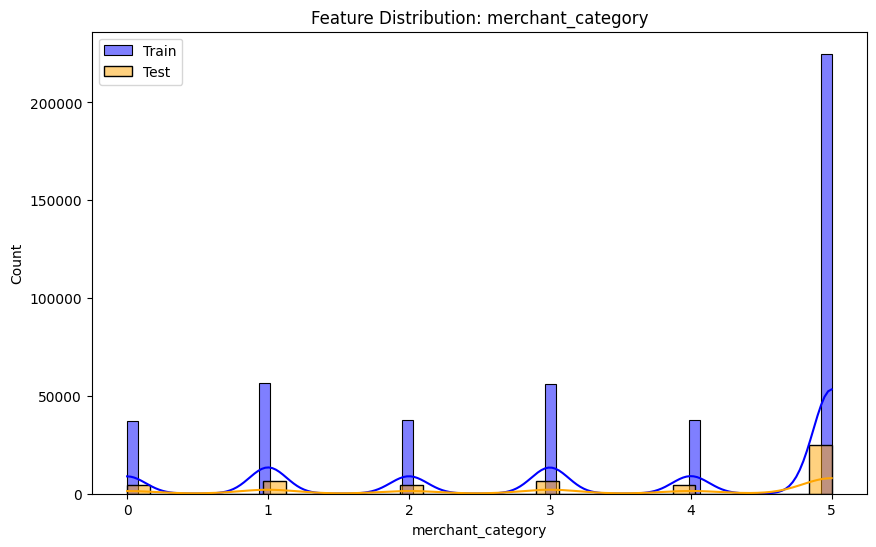

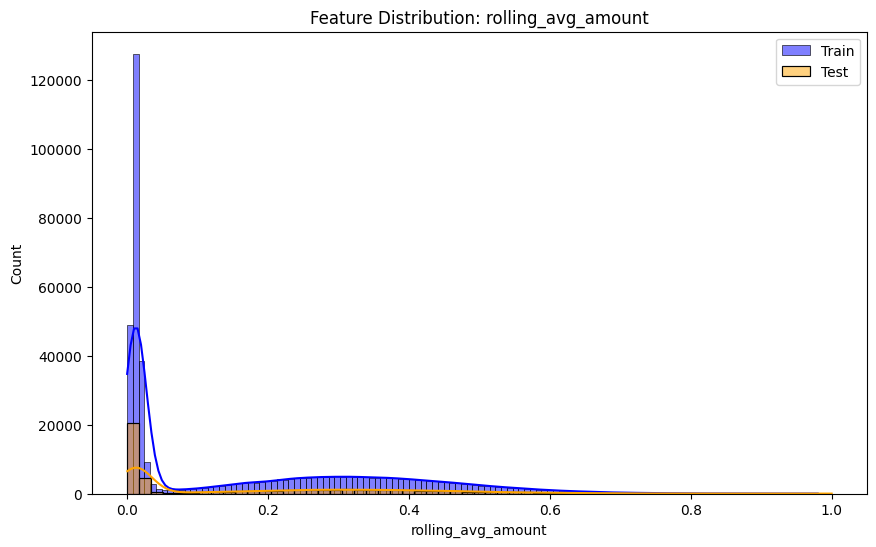

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot histograms of features in the training set
for feature in X_train.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(X_train[feature], kde=True, color="blue", label="Train")
    sns.histplot(X_test[feature], kde=True, color="orange", label="Test")
    plt.title(f"Feature Distribution: {feature}")
    plt.legend()
    plt.show()

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

def box_plot(col_name):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df_clean[col_name])
    plt.title(f"Boxplot of {col_name} (Outlier Detection)")
    plt.show()


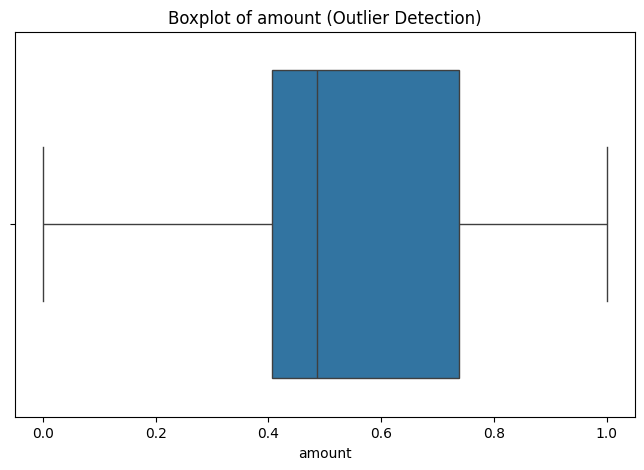

In [45]:
box_plot('amount')

In [42]:
# X_train.drop(columns=['lon', 'transaction_ratio'], axis=1, inplace=True)

In [43]:
X_train.columns

Index(['transaction_type', 'amount', 'merchant_category',
       'transaction_velocity', 'hour'],
      dtype='object')

## 4 layer model (128, 64, 32, 16), Dropout: 0.4, l2 = 0.001

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define the improved ANN model
def build_ann():
    model = keras.Sequential([
        layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)), 
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    
    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate the model
model_l1_l2 = build_ann()

# Add Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_l1_l2 = model_l1_l2.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, shuffle=True, callbacks=[early_stopping])


Epoch 1/10


/Users/UZAIR/Desktop/fraud_detection/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11250/11250 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9646 - loss: 0.1906 - val_accuracy: 0.9916 - val_loss: 0.0465
Epoch 2/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.9881 - loss: 0.0624 - val_accuracy: 0.9933 - val_loss: 0.0357
Epoch 3/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9897 - loss: 0.0514 - val_accuracy: 0.9996 - val_loss: 0.0145
Epoch 4/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.9903 - loss: 0.0475 - val_accuracy: 0.9941 - val_loss: 0.0251
Epoch 5/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.9920 - loss: 0.0410 - val_accuracy: 0.9997 - val_loss: 0.0139
Epoch 6/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9931 - loss: 0.0356 - val_accuracy: 0.9954 - val_loss: 0.0197
Epoch 7/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9915 - loss: 0.0409 - val_accuracy: 0.9997 - val_loss: 0.0142
Epoch 8/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9915 - lo

In [46]:
model_l1_l2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,021 (148.52 KB)

 Trainable params: 12,513 (48.88 KB)

 Non-trainable params: 480 (1.88 KB)

 Optimizer params: 25,028 (97.77 KB)

In [47]:
# Evaluate on test data
test_loss, test_acc = model_l1_l2.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"\nTest Loss: {test_loss:.9f}")


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9996 - loss: 0.0146  

Test Accuracy: 0.9996

Test Loss: 0.014519122


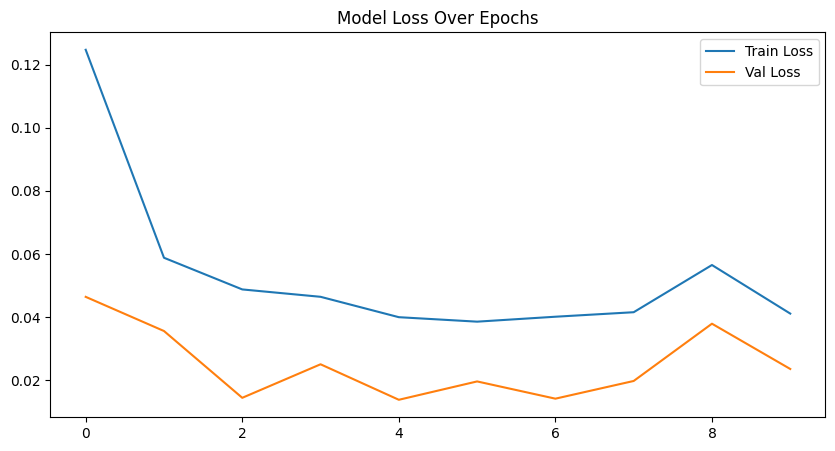

In [48]:
import matplotlib.pyplot as plt
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l1_l2.history['loss'], label='Train Loss')
plt.plot(history_l1_l2.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

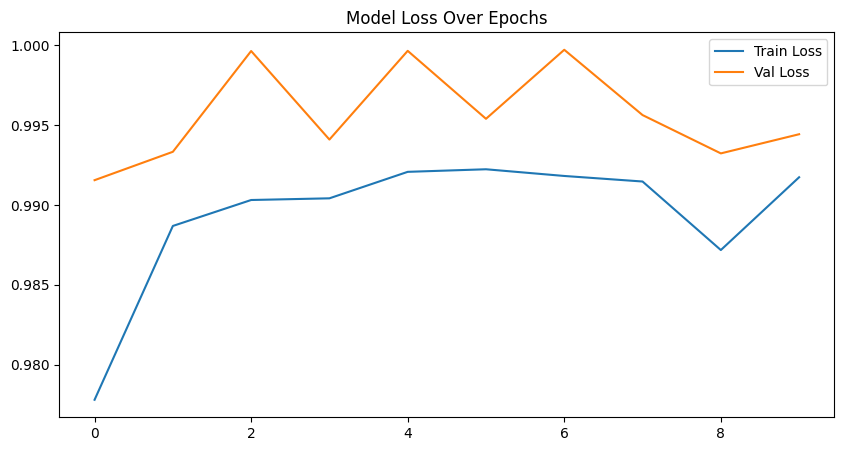

In [49]:

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l1_l2.history['accuracy'], label='Train Loss')
plt.plot(history_l1_l2.history['val_accuracy'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     25000
           1       1.00      1.00      1.00     25000

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



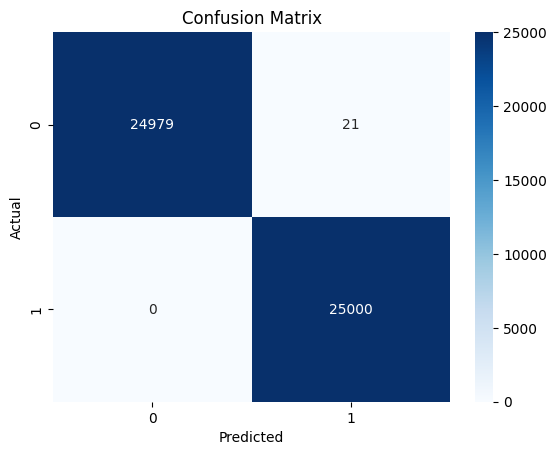

In [101]:
import seaborn as sns
# Predict fraud probabilities
y_pred = model_l1_l2.predict(X_test)
y_pred_labels = (y_pred > 0.5).astype(int)  # Convert to binary labels

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

print("Classification Report:\n", classification_report(y_test, y_pred_labels))

sns.heatmap(confusion_matrix(y_test, y_pred_labels), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 3 Layers Model, 64, 32, 16, droputout (0.4, 0.4, 0.3),  reg (l1,l2), lr = 0.0005 (adjustable with each epoch), batch_size = 32, epochs = 10

In [50]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

# Learning rate schedule
def lr_schedule(epoch):
    return 0.0005 * (0.95 ** epoch)  # Reduce LR every epoch

# Define the optimized model
def build_optimized_ann():
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),  # Proper Input layer

        layers.Dense(64, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),  
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),  

        layers.Dense(32, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),  
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),  

        layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),  
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),  

        layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])

    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

    return model

# Instantiate the model
model_l1_l2_03_04 = build_optimized_ann()

# Define callbacks
callbacks_list = [
    callbacks.LearningRateScheduler(lr_schedule),
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)  # Stops if no improvement
]

# Train the model
history_l1_l2_03_04 = model_l1_l2_03_04.fit(X_train, y_train, 
          epochs=10, 
          batch_size=32, 
          validation_split=0.2, 
          shuffle=True,
          callbacks=callbacks_list)


Epoch 1/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9602 - loss: 0.3023 - val_accuracy: 0.9892 - val_loss: 0.0637 - learning_rate: 5.0000e-04
Epoch 2/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9804 - loss: 0.0983 - val_accuracy: 0.9888 - val_loss: 0.0649 - learning_rate: 4.7500e-04
Epoch 3/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9815 - loss: 0.0954 - val_accuracy: 0.9919 - val_loss: 0.0519 - learning_rate: 4.5125e-04
Epoch 4/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9828 - loss: 0.0884 - val_accuracy: 0.9878 - val_loss: 0.0640 - learning_rate: 4.2869e-04
Epoch 5/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9821 - loss: 0.0921 - val_accuracy: 0.9921 - val_loss: 0.0520 - learning_rate: 4.0725e-04
Epoch 6/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9862 - loss: 0.0762 - val_accuracy: 0.9625 - val_loss: 0.1293 - learning_rate: 3.8689e-04
Epoch 7/10
11250/11250 ━━━━━━━━━━━

In [66]:
model_l1_l2_03_04.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,501 (41.02 KB)

 Trainable params: 3,425 (13.38 KB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 6,852 (26.77 KB)

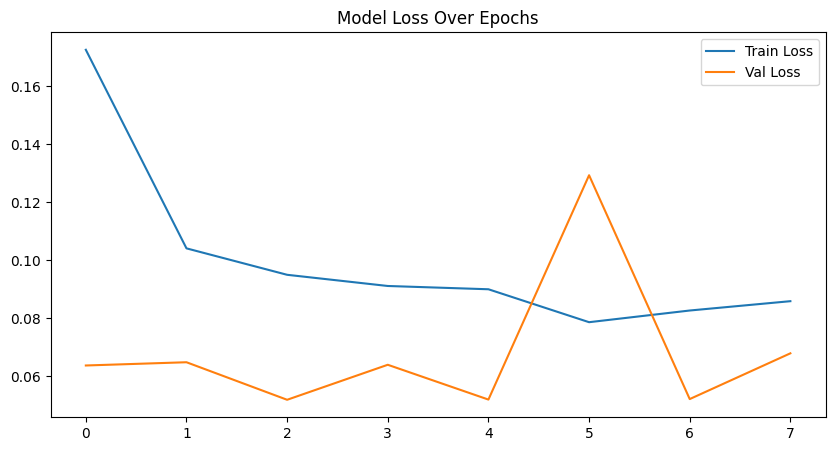

In [67]:
import matplotlib.pyplot as plt
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l1_l2_03_04.history['loss'], label='Train Loss')
plt.plot(history_l1_l2_03_04.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

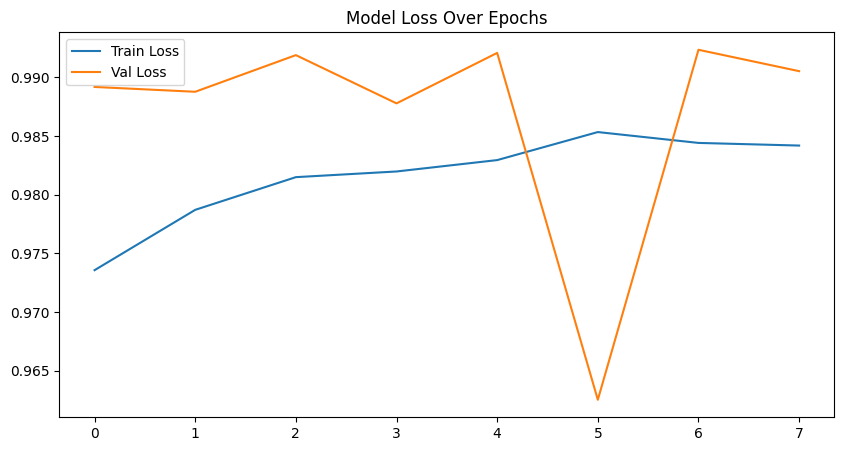

In [68]:

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l1_l2_03_04.history['accuracy'], label='Train Loss')
plt.plot(history_l1_l2_03_04.history['val_accuracy'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

In [69]:
# Evaluate on test data
test_loss, test_acc = model_l1_l2.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"\nTest Loss: {test_loss:.9f}")


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9996 - loss: 0.0146

Test Accuracy: 0.9996

Test Loss: 0.014519122


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     25000
           1       1.00      0.98      0.99     25000

    accuracy                           0.99     50000
   macro avg       0.99      0.99      0.99     50000
weighted avg       0.99      0.99      0.99     50000



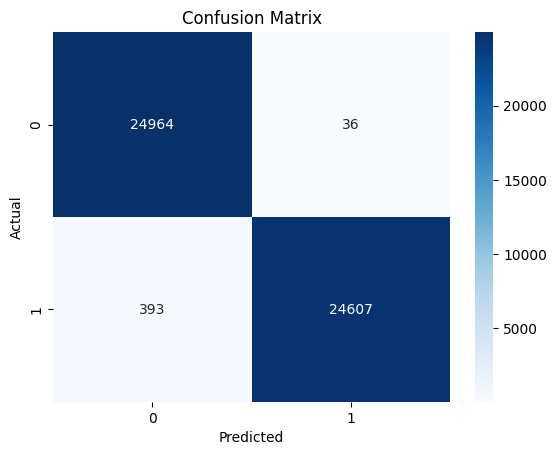

In [70]:
import seaborn as sns
# Predict fraud probabilities
y_pred = model_l1_l2_03_04.predict(X_test)
y_pred_labels = (y_pred > 0.5).astype(int)  # Convert to binary labels

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

print("Classification Report:\n", classification_report(y_test, y_pred_labels))

sns.heatmap(confusion_matrix(y_test, y_pred_labels), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 3 Layers (64, 32, 16), Dropout: (0.6, 0.6, 0.6) reg (l1 = 0.001, l2 = 0.001) activation = relu, sigmoid , lr = 0.0005, adjustable

In [56]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

# Learning rate schedule
def lr_schedule(epoch):
    return 0.0005 * (0.95 ** epoch)  # Reduce LR every epoch

# Define the optimized model
def build_optimized_ann():
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),  # Proper Input layer

        layers.Dense(64, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),  
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.6),  

        layers.Dense(32, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),  
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.6),  

        layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),  
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.6),  

        layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])

    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

    return model

# Instantiate the model
model_l1_l2_5d = build_optimized_ann()

# Define callbacks
callbacks_list = [
    callbacks.LearningRateScheduler(lr_schedule),
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)  # Stops if no improvement
]

# Train the model
history_l1_l2_5d = model_l1_l2_5d.fit(X_train, y_train, 
          epochs=10, 
          batch_size=32, 
          validation_split=0.2, 
          shuffle=True,
          callbacks=callbacks_list)


Epoch 1/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9035 - loss: 0.4666 - val_accuracy: 0.9847 - val_loss: 0.0848 - learning_rate: 5.0000e-04
Epoch 2/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9650 - loss: 0.1551 - val_accuracy: 0.9868 - val_loss: 0.0794 - learning_rate: 4.7500e-04
Epoch 3/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9665 - loss: 0.1519 - val_accuracy: 0.9865 - val_loss: 0.0860 - learning_rate: 4.5125e-04
Epoch 4/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9637 - loss: 0.1587 - val_accuracy: 0.9881 - val_loss: 0.0856 - learning_rate: 4.2869e-04
Epoch 5/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9691 - loss: 0.1409 - val_accuracy: 0.9830 - val_loss: 0.0938 - learning_rate: 4.0725e-04
Epoch 6/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9659 - loss: 0.1485 - val_accuracy: 0.9881 - val_loss: 0.0815 - learning_rate: 3.8689e-04
Epoch 7/10
11250/11250 ━━━━━━━━━━━

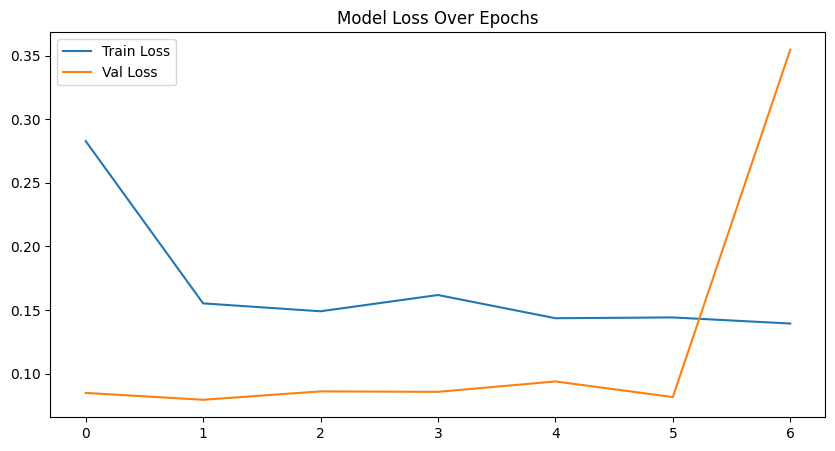

In [57]:
import matplotlib.pyplot as plt
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l1_l2_5d.history['loss'], label='Train Loss')
plt.plot(history_l1_l2_5d.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

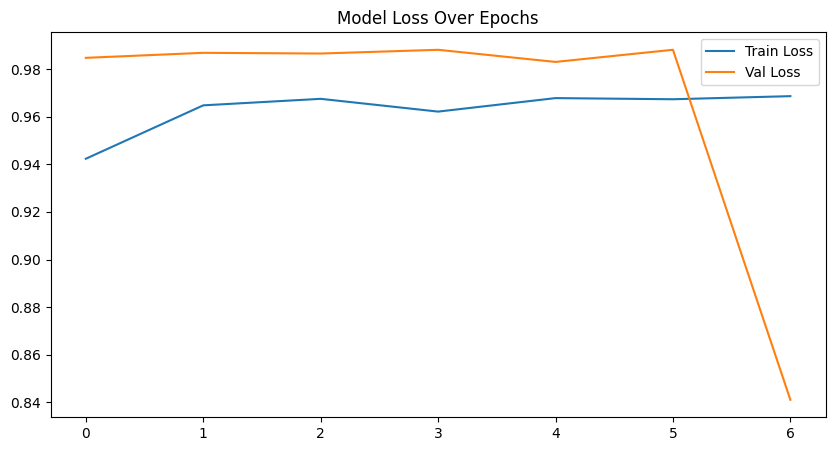

In [58]:
import matplotlib.pyplot as plt
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l1_l2_5d.history['accuracy'], label='Train Loss')
plt.plot(history_l1_l2_5d.history['val_accuracy'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

In [59]:
# Evaluate on test data
test_loss, test_acc = model_l1_l2_5d.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"\nTest Loss: {test_loss:.9f}")


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - accuracy: 0.9860 - loss: 0.0819

Test Accuracy: 0.9861

Test Loss: 0.081231296


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 640us/step
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     25000
           1       1.00      0.97      0.98     25000

    accuracy                           0.98     50000
   macro avg       0.98      0.98      0.98     50000
weighted avg       0.98      0.98      0.98     50000



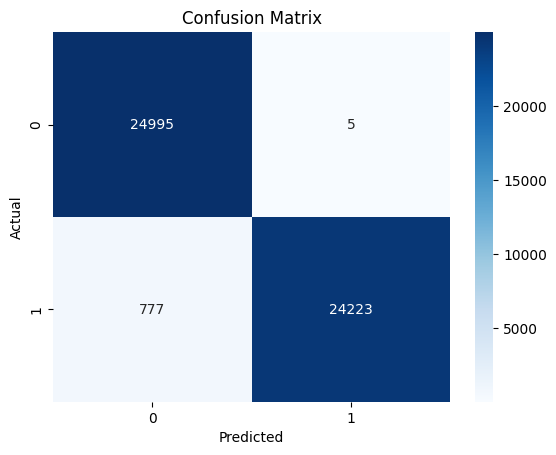

In [60]:
import seaborn as sns
# Predict fraud probabilities
y_pred = model_l1_l2_5d.predict(X_test)
y_pred_labels = (y_pred > 0.7).astype(int)  # Convert to binary labels

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

print("Classification Report:\n", classification_report(y_test, y_pred_labels))

sns.heatmap(confusion_matrix(y_test, y_pred_labels), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 3 layers (64, 32, 16)  reg(l2=0.001), activation=relu Dropout (0.5, 0.5, 0.4) lr = 0.0005 (adjustable) batch_size = 64

In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define the improved ANN model
def build_ann():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)), 
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    
    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate the model
model_l2_5d = build_ann()

# Add Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_l2_5d = model_l2_5d.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, shuffle=True, callbacks=[early_stopping])


2025-03-09 23:04:31.226113: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/10


/Users/UZAIR/Desktop/fraud_detection/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5625/5625 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9529 - loss: 0.1635 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 2/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9995 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 3/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9998 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 4/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9999 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 4.8389e-04
Epoch 5/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9999 - loss: 8.4279e-04 - val_accuracy: 1.0000 - val_loss: 6.1961e-04
Epoch 6/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9999 - loss: 7.2048e-04 - val_accuracy: 1.0000 - val_loss: 4.6944e-04
Epoch 7/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 6.6943e-04
Epoch 8/10
5625/5625 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9

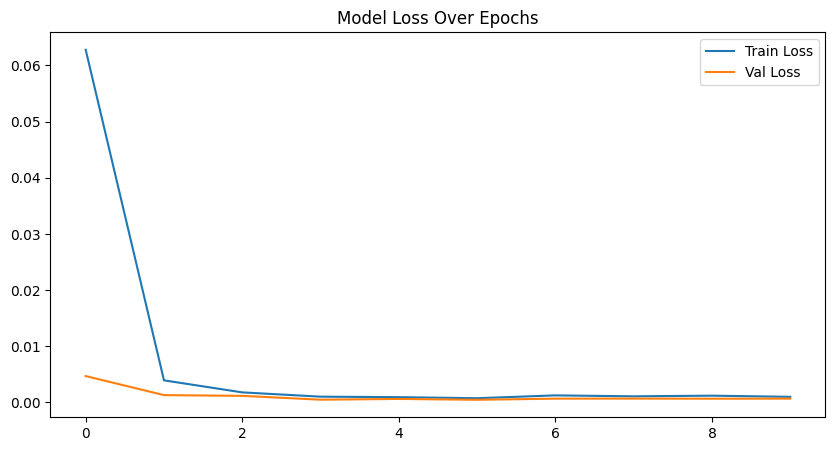

In [47]:
import matplotlib.pyplot as plt
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l2_5d.history['loss'], label='Train Loss')
plt.plot(history_l2_5d.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

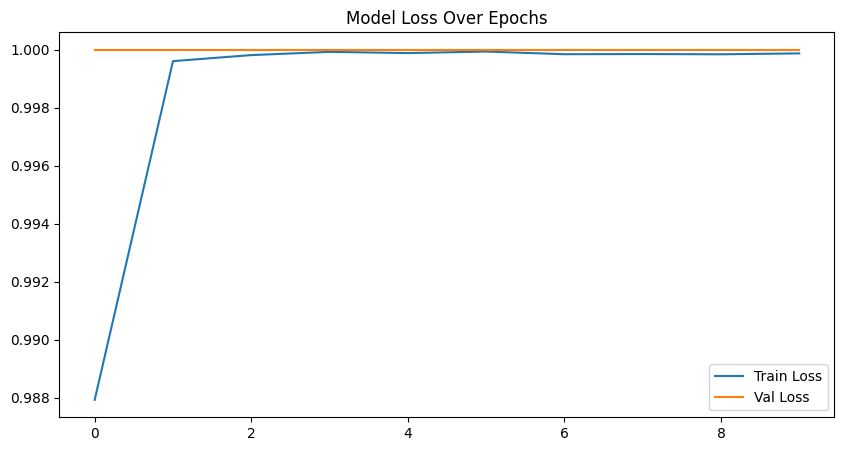

In [48]:
import matplotlib.pyplot as plt
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_l2_5d.history['accuracy'], label='Train Loss')
plt.plot(history_l2_5d.history['val_accuracy'], label='Val Loss')
plt.legend()
plt.title('Model Loss Over Epochs')
plt.show()

In [49]:
# Evaluate on test data
test_loss, test_acc = model_l2_5d.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"\nTest Loss: {test_loss:.9f}")


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 4.6944e-04

Test Accuracy: 1.0000

Test Loss: 0.000469442


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     25000
           1       1.00      1.00      1.00     25000

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



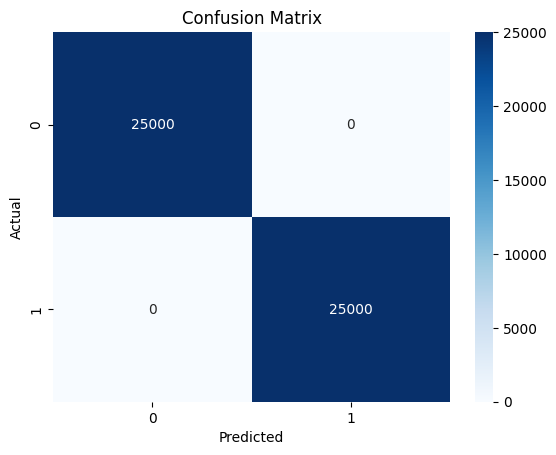

In [50]:
import seaborn as sns
# Predict fraud probabilities
y_pred = model_l2_5d.predict(X_test)
y_pred_labels = (y_pred > 0.7).astype(int)  # Convert to binary labels

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

print("Classification Report:\n", classification_report(y_test, y_pred_labels))

sns.heatmap(confusion_matrix(y_test, y_pred_labels), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [53]:
model_l2_5d.save("../backend_app/trained_model_weights/latest_fraud_model.keras")

## Monitor Data Drift with JSD & Wasserstein Distance

In [34]:
prod_df = pd.read_csv('clean_prod_data.csv')
prod_df.head()

,transaction_type,amount,merchant_category,is_fraudulent,transaction_velocity,rolling_avg_amount,hour,lon,transaction_ratio
0,1,0.598697,1,0,0.0,250.39,4,0.155798,0.010803
1,2,0.397103,4,0,0.0,43.20,3,0.031772,0.002675
2,3,0.397103,3,0,0.0,43.20,14,0.218584,0.001674
3,2,0.605188,2,0,0.0,264.86,5,0.062851,0.010686
4,3,0.511592,3,0,0.0,117.62,12,0.163653,0.006884


In [ ]:
# prod_clean_df = preprocessing(prod_df)

In [76]:
df_clean.columns

Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'transaction_velocity', 'rolling_avg_amount', 'hour', 'lon',
       'transaction_ratio'],
      dtype='object')

In [77]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

# Define the numerical features to monitor
features = ['amount', 'transaction_velocity', 'rolling_avg_amount', 'hour', 'lon', 'transaction_ratio']

# Initialize drift results
drift_results = {}

for feature in features:
    # Get the distributions
    old_dist = df_clean[feature].dropna().values
    new_dist = prod_df[feature].dropna().values

    # Compute JSD and Wasserstein Distance
    jsd_value = jensenshannon(np.histogram(old_dist, bins=50, density=True)[0], 
                              np.histogram(new_dist, bins=50, density=True)[0])
    
    w_dist = wasserstein_distance(old_dist, new_dist)

    # Store results
    drift_results[feature] = {'JSD': jsd_value, 'Wasserstein': w_dist}

# Print drift scores
print("Drift Results:", drift_results)


Drift Results: {'amount': {'JSD': 0.3457715634985325, 'Wasserstein': 0.1292713544362462}, 'transaction_velocity': {'JSD': 0.2513109548469883, 'Wasserstein': 0.16121554760503246}, 'rolling_avg_amount': {'JSD': 0.43728996337290943, 'Wasserstein': 1071.253027643086}, 'hour': {'JSD': 0.13847269763344058, 'Wasserstein': 2.215115999999999}, 'lon': {'JSD': 0.4395384184395373, 'Wasserstein': 0.37618006261830605}, 'transaction_ratio': {'JSD': 0.3219449425838748, 'Wasserstein': 0.1104315336485943}}


In [84]:
df_clean_p1_leg = df_clean[:250000]
df_clean_p1_fra = df_clean[250000:]

In [88]:
print(df_clean_p1_leg['is_fraudulent'].value_counts())
print(df_clean_p1_fra['is_fraudulent'].value_counts())

is_fraudulent
0    250000
Name: count, dtype: int64
is_fraudulent
1    250000
Name: count, dtype: int64


In [91]:
old_data = pd.concat([df_clean_p1_leg[:125000], df_clean_p1_fra[:125000]], axis=0)
new_data = pd.concat([df_clean_p1_leg[125000:], df_clean_p1_fra[125000:]], axis=0)

In [93]:
historical_jsd_values = []

features = ['amount', 'transaction_velocity', 'rolling_avg_amount', 'hour', 'lon', 'transaction_ratio']
for feature in features:

    old_hist, _ = np.histogram(old_data[feature], bins=50, density=True)
    new_hist, _ = np.histogram(new_data[feature], bins=50, density=True)

    jsd_value = jensenshannon(old_hist, new_hist)
    historical_jsd_values.append(jsd_value)

# Compute statistics
mean_jsd = np.mean(historical_jsd_values)
std_jsd = np.std(historical_jsd_values)
max_jsd = np.max(historical_jsd_values)

print(f"Mean JSD: {mean_jsd:.4f}, Std Dev: {std_jsd:.4f}, Max JSD: {max_jsd:.4f}")


Mean JSD: 0.0840, Std Dev: 0.1494, Max JSD: 0.4164


In [94]:
JSD_THRESHOLD = mean_jsd + 2 * std_jsd  # Adjust multiplier based on sensitivity
print(f"Recommended JSD threshold: {JSD_THRESHOLD:.4f}")


Recommended JSD threshold: 0.3829


## WSD: 

In [99]:
historical_emd_values = []

features = ['amount', 'transaction_velocity', 'rolling_avg_amount', 'hour', 'lon', 'transaction_ratio']
for feature in features:

    old_hist, _ = np.histogram(old_data[feature], bins=50, density=True)
    new_hist, _ = np.histogram(new_data[feature], bins=50, density=True)
 
    #Compute Wasserstein Distance
    emd_value = wasserstein_distance(old_hist, new_hist)

    print(f"Wasserstein Distance (EMD): {emd_value}")

    historical_emd_values.append(emd_value)

# Compute statistics
mean_jsd = np.mean(historical_emd_values)
std_jsd = np.std(historical_emd_values)
max_jsd = np.max(historical_emd_values)

print(f"Mean JSD: {mean_jsd:.4f}, Std Dev: {std_jsd:.4f}, Max JSD: {max_jsd:.4f}")


Wasserstein Distance (EMD): 0.013051319883387215
Wasserstein Distance (EMD): 0.09695309717436229
Wasserstein Distance (EMD): 9.103104648004579e-06
Wasserstein Distance (EMD): 0.00012278260869567795
Wasserstein Distance (EMD): 0.003503902919317195
Wasserstein Distance (EMD): 0.06471477306922416
Mean JSD: 0.0297, Std Dev: 0.0376, Max JSD: 0.0970


In [100]:
JSD_THRESHOLD = mean_jsd + 2 * std_jsd  # Adjust multiplier based on sensitivity
print(f"Recommended JSD threshold: {JSD_THRESHOLD:.4f}")

Recommended JSD threshold: 0.1049


shap_values: (1, 4) [[0.  0.4 0.1 0.7]]
base_values: (1, 1) [[2.10993541e-17]]
data_values: (1, 4) [[0.  0.3 0.2 0.8]]


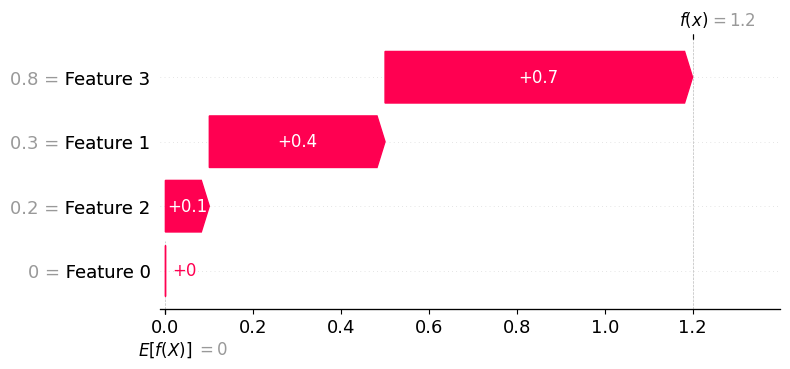

In [66]:
import numpy as np
import shap
import matplotlib.pyplot as plt


# Given JSON-like data
data_dict = {
    "shap_values": [[0.0, 0.4, 0.1, 0.7]],
    "base_values": [[2.109935414244943e-17]],
    "data_values": [[0.0, 0.3, 0.2, 0.8]]
}

# Convert to NumPy arrays
shap_values = np.array(data_dict["shap_values"])
base_values = np.array(data_dict["base_values"])
data_values = np.array(data_dict["data_values"])

# Print shapes to confirm
print("shap_values:", shap_values.shape, shap_values)
print("base_values:", base_values.shape, base_values)
print("data_values:", data_values.shape, data_values)

# Use for SHAP visualization
# shap.summary_plot(shap_values, data_values)
shap.waterfall_plot(shap.Explanation(values=shap_values[0], base_values=base_values, data=data_values[0]))


In [68]:
import base64
from io import BytesIO
from PIL import Image

# Your base64 string (shortened for brevity)
base64_string = """..."""

# Decode the base64 string
image_data = base64.b64decode(base64_string)

# Open and display the image
image = Image.open(BytesIO(image_data))
image.show()